# Métodos Monte Carlo en Taxi-v3
## Comparativa: On-Policy · Off-Policy Ordinary IS · Off-Policy Weighted IS

---

### ¿Qué es Monte Carlo en RL?

Los métodos Monte Carlo (MC) aprenden **directamente de la experiencia** sin necesidad de un modelo del entorno. La idea central es:

> "Juega episodios completos y usa el retorno real obtenido para actualizar lo que crees saber de cada estado-acción"

El **retorno** desde el instante $t$ hasta el final del episodio es:
$$G_t = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + \dots + \gamma^{T-t-1} R_T$$

La tabla $Q(s,a)$ se actualiza como la **media de todos los retornos** observados cuando se estuvo en $s$ y se tomó $a$:
$$Q(s,a) \leftarrow Q(s,a) + \frac{1}{N(s,a)}\bigl[G_t - Q(s,a)\bigr]$$

---

### Los tres algoritmos de este notebook

| Algoritmo | Politica que mejora | Como explora | Correccion |
|---|---|---|---|
| **On-Policy (First-Visit)** | e-greedy (la misma) | e-greedy | No necesita |
| **Off-Policy Ordinary IS** | greedy optima pi | e-greedy b | Ratio sin ponderar |
| **Off-Policy Weighted IS** | greedy optima pi | e-greedy b | Ratio ponderado |

---

### Entorno: Taxi-v3

- **500 estados** discretos = 25 posiciones taxi x 5 posiciones pasajero x 4 destinos
- **6 acciones**: Sur(0), Norte(1), Este(2), Oeste(3), Recoger(4), Dejar(5)
- **Recompensas**: +20 entrega correcta · -10 accion ilegal · -1 por cada paso
- **Por que es ideal para MC tabular**: espacio finito → cabe en una tabla Q de 500x6

In [1]:
# Instalacion de dependencias
# gymnasium[toy-text] incluye el entorno Taxi-v3
!pip install gymnasium[toy-text] --quiet


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Semilla
SEED = 123
np.random.seed(SEED)

In [3]:
# Verificar entorno
env_test = gym.make('Taxi-v3')
print(f"Gymnasium v{gym.__version__}")
print(f"Estados : {env_test.observation_space.n}")
print(f"Acciones: {env_test.action_space.n}  (Sur, Norte, Este, Oeste, Recoger, Dejar)")
env_test.close()

Gymnasium v1.2.3
Estados : 500
Acciones: 6  (Sur, Norte, Este, Oeste, Recoger, Dejar)


In [4]:
# ============================================================
# HIPERPARAMETROS GLOBALES
# Todos los agentes comparten la misma configuracion para que
# la comparativa sea justa.
# ============================================================

N_EPISODES    = 15_000   # episodios de entrenamiento por agente
GAMMA         = 0.99     # factor de descuento
                         # cercano a 1 = valoramos mucho el futuro
EPSILON_START = 1.0      # exploracion inicial: 100% aleatorio
EPSILON_END   = 0.05     # exploracion minima: siempre al menos 5%
EPSILON_DECAY = 0.9997   # multiplicamos epsilon por este valor cada episodio
                         # epsilon llega a 0.05 aproximadamente en el ep. 10.000

EVAL_EVERY   = 300       # cada cuantos episodios evaluamos el agente
N_EVAL_EPS   = 50        # episodios de evaluacion (sin exploracion, politica greedy pura)

# Exclusivo de Off-Policy Ordinary IS:
# los ratios W pueden crecer exponencialmente, limitamos su valor
W_MAX_ORDINARY = 5.0

print(f"Episodios : {N_EPISODES:,}")
print(f"Gamma     : {GAMMA}")
print(f"Epsilon   : {EPSILON_START} -> {EPSILON_END} (decay={EPSILON_DECAY})")

Episodios : 15,000
Gamma     : 0.99
Epsilon   : 1.0 -> 0.05 (decay=0.9997)


In [5]:
# ============================================================
# FUNCIONES AUXILIARES COMPARTIDAS POR LOS TRES ALGORITMOS
# ============================================================

def epsilon_greedy(Q, state, epsilon, n_actions):
    """
    Politica epsilon-greedy.

    Con probabilidad epsilon -> accion aleatoria    (EXPLORACION)
    Con probabilidad 1-epsilon -> argmax Q(s, .)   (EXPLOTACION)

    Esta es la politica de comportamiento b usada por los tres agentes
    para generar episodios.
    """
    if np.random.random() < epsilon:
        return np.random.randint(n_actions)   # accion aleatoria
    return int(np.argmax(Q[state]))           # mejor accion conocida


def generate_episode(env, Q, epsilon, n_actions):
    """
    Genera UN episodio completo siguiendo politica epsilon-greedy.

    MC necesita episodios COMPLETOS porque necesita el retorno real G
    hasta el final. No puede actualizar a mitad del episodio (a diferencia de TD).

    Returns:
        lista de tuplas (estado, accion, recompensa) - una por cada paso
    """
    episode = []
    state, _ = env.reset(seed=np.random.randint(10000))
    done = False

    while not done:
        action = epsilon_greedy(Q, state, epsilon, n_actions)
        next_state, reward, terminated, truncated, _ = env.step(action)
        episode.append((state, action, reward))
        done  = terminated or truncated
        state = next_state

    return episode


def evaluate_agent(env, Q, n_episodes=50):
    """
    Evalua la politica GREEDY PURA del agente (epsilon=0, sin exploracion).

    Es el indicador mas limpio del aprendizaje real:
    mide lo que el agente haría si tuviera que actuar en el mundo real.

    Returns:
        (media de recompensa acumulada, desviacion estandar)
    """
    rewards = []
    for _ in range(n_episodes):
        state, _ = env.reset()
        done = False
        total_reward = 0
        while not done:
            action = int(np.argmax(Q[state]))  # greedy puro
            state, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            done = terminated or truncated
        rewards.append(total_reward)
    return np.mean(rewards), np.std(rewards)


def smooth(values, window=300):
    """
    Media movil para suavizar curvas de aprendizaje ruidosas.
    Los episodios individuales tienen mucha varianza;
    la media movil revela la tendencia de fondo.
    """
    return np.convolve(values, np.ones(window) / window, mode='valid')


print("Funciones auxiliares definidas")

Funciones auxiliares definidas


---
## Algoritmo 1 — MC On-Policy: First-Visit Control

### Idea clave
El agente usa **una sola politica** para todo: explora con epsilon-greedy Y aprende sobre esa misma politica.

### Por que 'First-Visit'
En un episodio, el mismo par (s,a) puede aparecer varias veces. 'First-Visit' significa que solo usamos la **primera aparicion** para calcular G, garantizando independencia estadistica entre las muestras.

### Pseudocodigo
```
Inicializar Q(s,a) = 0, N(s,a) = 0

Para cada episodio:
    1. Generar episodio con politica epsilon-greedy
    2. G = 0
    3. Recorrer el episodio al reves:
       G <- gamma*G + R
       Si (s, a) no visitado aun:
           N(s,a) += 1
           Q(s,a) <- Q(s,a) + [G - Q(s,a)] / N(s,a)   <- media incremental
    4. epsilon <- max(epsilon_min, epsilon * decay)
```

In [6]:
def mc_on_policy(env, n_episodes, gamma, epsilon_start, epsilon_end, epsilon_decay, eval_every=300, n_eval=50):
    """
    Monte Carlo On-Policy: First-Visit MC Control con epsilon-greedy.

    La politica que se mejora es la misma que genera los episodios.
    Aprendemos sobre la politica epsilon-greedy, no sobre la greedy optima.
    A medida que epsilon -> 0, la politica se aproxima a la optima.
    """
    n_states  = env.observation_space.n   # 500 en Taxi-v3
    n_actions = env.action_space.n        # 6 en Taxi-v3

    # Tabla Q[estado][accion] = valor estimado de tomar 'accion' en 'estado'
    Q = np.zeros((n_states, n_actions))

    # N[estado][accion] = numero de veces que hemos visitado (s,a)
    # Necesario para la media incremental: Q <- Q + (G - Q) / N
    N = np.zeros((n_states, n_actions))

    epsilon        = epsilon_start
    train_rewards  = []   # reward total por episodio (con exploracion)
    eval_rewards   = []   # reward medio en evaluacion greedy periodica
    eval_stds      = []   # desviacion estandar de la evaluacion
    eval_episodes  = []   # episodio en que se evaluo
    episode_lengths = []  # numero de pasos por episodio
    epsilon_history = []  # valor de epsilon por episodio

    for ep in tqdm(range(n_episodes), desc="MC On-Policy  ", colour='blue'):

        # PASO 1: Generar episodio completo con politica epsilon-greedy
        # MC NECESITA el episodio completo antes de poder actualizar
        episode = generate_episode(env, Q, epsilon, n_actions)
        train_rewards.append(sum(r for _, _, r in episode))
        episode_lengths.append(len(episode))
        epsilon_history.append(epsilon)

        # PASO 2: Calcular retornos y actualizar Q (First-Visit)
        G = 0.0          # retorno acumulado, empieza en 0 al final del episodio
        visited = set()  # pares (s,a) ya procesados en este episodio (First-Visit)

        # Recorremos AL REVES para acumular G eficientemente:
        # G_t = R_{t+1} + gamma * G_{t+1}
        # Si fuera adelante necesitariamos sumar todas las recompensas futuras
        for state, action, reward in reversed(episode):

            # Actualizar retorno acumulado
            G = gamma * G + reward

            # First-Visit: solo procesamos la PRIMERA ocurrencia de (s,a)
            if (state, action) not in visited:
                visited.add((state, action))

                N[state, action] += 1

                # Media incremental de los retornos G vistos para (s,a)
                # Equivale a: Q(s,a) = media de todos los G historicos
                # pero sin necesidad de guardarlos todos
                Q[state, action] += (G - Q[state, action]) / N[state, action]

        # PASO 3: Reducir exploracion
        # Al principio exploramos mucho (epsilon~1), al final casi no (epsilon~epsilon_end)
        epsilon = max(epsilon_end, epsilon * epsilon_decay)

        # PASO 4: Evaluacion periodica con politica greedy pura
        if (ep + 1) % eval_every == 0:
            mean_r, std_r = evaluate_agent(env, Q, n_eval)
            eval_rewards.append(mean_r)
            eval_stds.append(std_r)
            eval_episodes.append(ep + 1)

    return Q, train_rewards, eval_rewards, eval_stds, eval_episodes, episode_lengths, epsilon_history


env = gym.make('Taxi-v3')
print("Entrenando MC On-Policy...")
Q_on, train_on, eval_on, std_on, eps_on, lengths_on, eps_hist_on = mc_on_policy(
    env, N_EPISODES, GAMMA, EPSILON_START, EPSILON_END, EPSILON_DECAY, EVAL_EVERY, N_EVAL_EPS
)
print(f"Resultado final (greedy, {N_EVAL_EPS} ep): {eval_on[-1]:.2f} +/- {std_on[-1]:.2f}")
print(f"Mejor evaluacion: {max(eval_on):.2f}")

Entrenando MC On-Policy...


MC On-Policy  : 100%|██████████| 15000/15000 [00:43<00:00, 342.87it/s]

Resultado final (greedy, 50 ep): -325.20 +/- 565.58
Mejor evaluacion: -173.00


---
## Algoritmo 2 — MC Off-Policy: Ordinary Importance Sampling

### Por que off-policy?
On-policy aprende sobre la politica epsilon-greedy, que **no es la optima** (siempre tiene algo de aleatoriedad). Off-policy separa exploracion y aprendizaje:
- **Politica de comportamiento b** (behaviour): epsilon-greedy → explora el entorno
- **Politica objetivo pi** (target): greedy → la que queremos aprender y es optima

### El ratio de importancia
Para usar retornos generados con b para estimar valores bajo pi:
$$\rho_{t:T} = \prod_{k=t}^{T-1} \frac{\pi(A_k|S_k)}{b(A_k|S_k)}$$

### Ordinary IS
$$Q(s,a) \leftarrow Q(s,a) + \frac{1}{N}[W \cdot G - Q(s,a)]$$

**Problema**: varianza muy alta porque W puede crecer exponencialmente

In [7]:
def mc_off_ordinary(env, n_episodes, gamma, epsilon_start, epsilon_end, epsilon_decay,
                    w_max=5.0, eval_every=300, n_eval=50):
    """
    Monte Carlo Off-Policy con Ordinary Importance Sampling.

    Aprende la politica greedy optima usando episodios generados por epsilon-greedy.

    Ordinary IS: el retorno se pondera directamente por W sin normalizar
        - Sin sesgo
        - Alta varianza (W puede crecer exponencialmente en episodios largos)
        - Solucion practica: clipping de W (w_max) para estabilidad numerica

    Diferencia clave con Weighted IS:
        Ordinary: Q <- Q + (W*G - Q) / N
        Weighted: C += W; Q <- Q + (W/C)*(G - Q)
    """
    n_states  = env.observation_space.n
    n_actions = env.action_space.n

    Q = np.zeros((n_states, n_actions))  # tabla de valores
    N = np.zeros((n_states, n_actions))  # contador de visitas

    epsilon        = epsilon_start
    train_rewards  = []
    eval_rewards   = []
    eval_stds      = []
    eval_episodes  = []
    episode_lengths = []
    epsilon_history = []

    for ep in tqdm(range(n_episodes), desc="MC Off Ordinary", colour='red'):

        # Generar episodio con politica de comportamiento b (epsilon-greedy)
        episode = generate_episode(env, Q, epsilon, n_actions)
        train_rewards.append(sum(r for _, _, r in episode))
        episode_lengths.append(len(episode))
        epsilon_history.append(epsilon)

        G = 0.0    # retorno acumulado
        W = 1.0    # ratio de importancia acumulado (producto de pi/b)

        for state, action, reward in reversed(episode):

            G = gamma * G + reward

            # Actualizacion con Ordinary IS:
            # Q(s,a) <- Q(s,a) + (W*G - Q(s,a)) / N
            # Si W=1 (accion greedy): identico a on-policy
            # Si W>1: amplificamos el retorno para compensar la diferencia de politicas
            N[state, action] += 1
            Q[state, action] += (W * G - Q[state, action]) / N[state, action]

            # Calcular ratio pi(a|s) / b(a|s) para el siguiente paso
            greedy_action = int(np.argmax(Q[state]))  # accion que pi elegiria

            if action != greedy_action:
                # pi(accion_no_greedy | s) = 0  ->  ratio = 0  ->  W = 0
                # Con W=0 el resto del episodio no aporta informacion sobre pi
                W = 0.0
                break

            # Si la accion fue greedy: pi(a|s) = 1
            # b(a_greedy|s) = (1-epsilon) + epsilon/|A|  (epsilon-greedy)
            prob_b = (1.0 - epsilon) + (epsilon / n_actions)
            W = W * (1.0 / prob_b)  # W *= pi/b = 1/prob_b

            # Clipping de W para evitar actualizaciones desestabilizadoras
            # Ordinary IS sin clipping puede tener W muy grande en episodios largos
            W = min(W, w_max)

        epsilon = max(epsilon_end, epsilon * epsilon_decay)

        if (ep + 1) % eval_every == 0:
            mean_r, std_r = evaluate_agent(env, Q, n_eval)
            eval_rewards.append(mean_r)
            eval_stds.append(std_r)
            eval_episodes.append(ep + 1)

    return Q, train_rewards, eval_rewards, eval_stds, eval_episodes, episode_lengths, epsilon_history


print("Entrenando MC Off-Policy (Ordinary IS)...")
Q_ord, train_ord, eval_ord, std_ord, eps_ord, lengths_ord, eps_hist_ord = mc_off_ordinary(
    env, N_EPISODES, GAMMA, EPSILON_START, EPSILON_END, EPSILON_DECAY,
    w_max=W_MAX_ORDINARY, eval_every=EVAL_EVERY, n_eval=N_EVAL_EPS
)
print(f"Resultado final (greedy, {N_EVAL_EPS} ep): {eval_ord[-1]:.2f} +/- {std_ord[-1]:.2f}")
print(f"Mejor evaluacion: {max(eval_ord):.2f}")

Entrenando MC Off-Policy (Ordinary IS)...


MC Off Ordinary: 100%|██████████| 15000/15000 [00:34<00:00, 439.53it/s]

Resultado final (greedy, 50 ep): -72.32 +/- 99.98
Mejor evaluacion: -46.68


---
## Algoritmo 3 — MC Off-Policy: Weighted Importance Sampling

### Por que es mejor que Ordinary IS?

En lugar de ponderar el retorno directamente por W, **normalizamos** los pesos:
$$Q(s,a) = \frac{\sum_{i} W_i G_i}{\sum_{i} W_i}$$

Esto se implementa de forma incremental con un acumulador C(s,a):
$$C(s,a) \leftarrow C(s,a) + W$$
$$Q(s,a) \leftarrow Q(s,a) + \frac{W}{C(s,a)}\bigl[G - Q(s,a)\bigr]$$

| | Ordinary IS | Weighted IS |
|---|---|---|
| Sesgo | Sin sesgo | Con sesgo (desaparece asintoticamente) |
| Varianza | Alta | Mucho menor |
| Convergencia | Inestable | Estable |
| Preferido | No | **Si** |

In [8]:
def mc_off_weighted(env, n_episodes, gamma, epsilon_start, epsilon_end, epsilon_decay,
                    eval_every=300, n_eval=50):
    """
    Monte Carlo Off-Policy con Weighted Importance Sampling.

    Aprende la politica greedy optima con menor varianza que Ordinary IS.
    La clave es que el denominador de la actualizacion tambien depende de W,
    lo que reduce el efecto de los ratios extremos.

    No necesitamos clipping de W porque la normalizacion por C(s,a)
    ya controla la magnitud de la actualizacion de forma natural.
    """
    n_states  = env.observation_space.n
    n_actions = env.action_space.n

    Q = np.zeros((n_states, n_actions))  # tabla de valores

    # C[s,a] = suma acumulada de todos los pesos W para (s,a)
    # Es el denominador de Weighted IS. Comienza en 0.
    C = np.zeros((n_states, n_actions))

    epsilon        = epsilon_start
    train_rewards  = []
    eval_rewards   = []
    eval_stds      = []
    eval_episodes  = []
    episode_lengths = []
    epsilon_history = []

    for ep in tqdm(range(n_episodes), desc="MC Off Weighted", colour='green'):

        # Generar episodio con politica de comportamiento b (epsilon-greedy)
        episode = generate_episode(env, Q, epsilon, n_actions)
        train_rewards.append(sum(r for _, _, r in episode))
        episode_lengths.append(len(episode))
        epsilon_history.append(epsilon)

        G = 0.0    # retorno acumulado
        W = 1.0    # ratio de importancia acumulado

        for state, action, reward in reversed(episode):

            G = gamma * G + reward

            # Actualizacion de Weighted IS:
            # 1) Acumulamos el peso W en C(s,a)  <- denominador de la media ponderada
            C[state, action] += W

            # 2) Actualizamos Q con el peso normalizado W/C
            #    Equivale a la media ponderada: Q = sum(W_i * G_i) / sum(W_i)
            Q[state, action] += (W / C[state, action]) * (G - Q[state, action])

            # Calcular ratio pi(a|s) / b(a|s)
            greedy_action = int(np.argmax(Q[state]))

            if action != greedy_action:
                # pi(a_no_greedy|s) = 0  ->  ratio = 0  ->  W = 0
                # En Weighted IS cortamos el episodio (igual que Ordinary IS)
                # pero a diferencia de Ordinary, NO acumulamos W=0 en C
                # -> los pasos ya procesados mantienen su contribucion
                break

            # Si la accion fue greedy: pi(a|s) = 1
            # b(a_greedy|s) = (1-epsilon) + epsilon/|A|  (epsilon-greedy)
            prob_b = (1.0 - epsilon) + (epsilon / n_actions)
            W = W * (1.0 / prob_b)

            # No necesitamos clipping: la normalizacion por C controla la magnitud

        epsilon = max(epsilon_end, epsilon * epsilon_decay)

        if (ep + 1) % eval_every == 0:
            mean_r, std_r = evaluate_agent(env, Q, n_eval)
            eval_rewards.append(mean_r)
            eval_stds.append(std_r)
            eval_episodes.append(ep + 1)

    return Q, train_rewards, eval_rewards, eval_stds, eval_episodes, episode_lengths, epsilon_history


print("Entrenando MC Off-Policy (Weighted IS)...")
Q_wis, train_wis, eval_wis, std_wis, eps_wis, lengths_wis, eps_hist_wis = mc_off_weighted(
    env, N_EPISODES, GAMMA, EPSILON_START, EPSILON_END, EPSILON_DECAY,
    eval_every=EVAL_EVERY, n_eval=N_EVAL_EPS
)
print(f"Resultado final (greedy, {N_EVAL_EPS} ep): {eval_wis[-1]:.2f} +/- {std_wis[-1]:.2f}")
print(f"Mejor evaluacion: {max(eval_wis):.2f}")
env.close()

Entrenando MC Off-Policy (Weighted IS)...


MC Off Weighted: 100%|██████████| 15000/15000 [00:22<00:00, 659.98it/s] 

Resultado final (greedy, 50 ep): -12.42 +/- 62.60
Mejor evaluacion: 3.86


---
## Visualizacion Comparativa

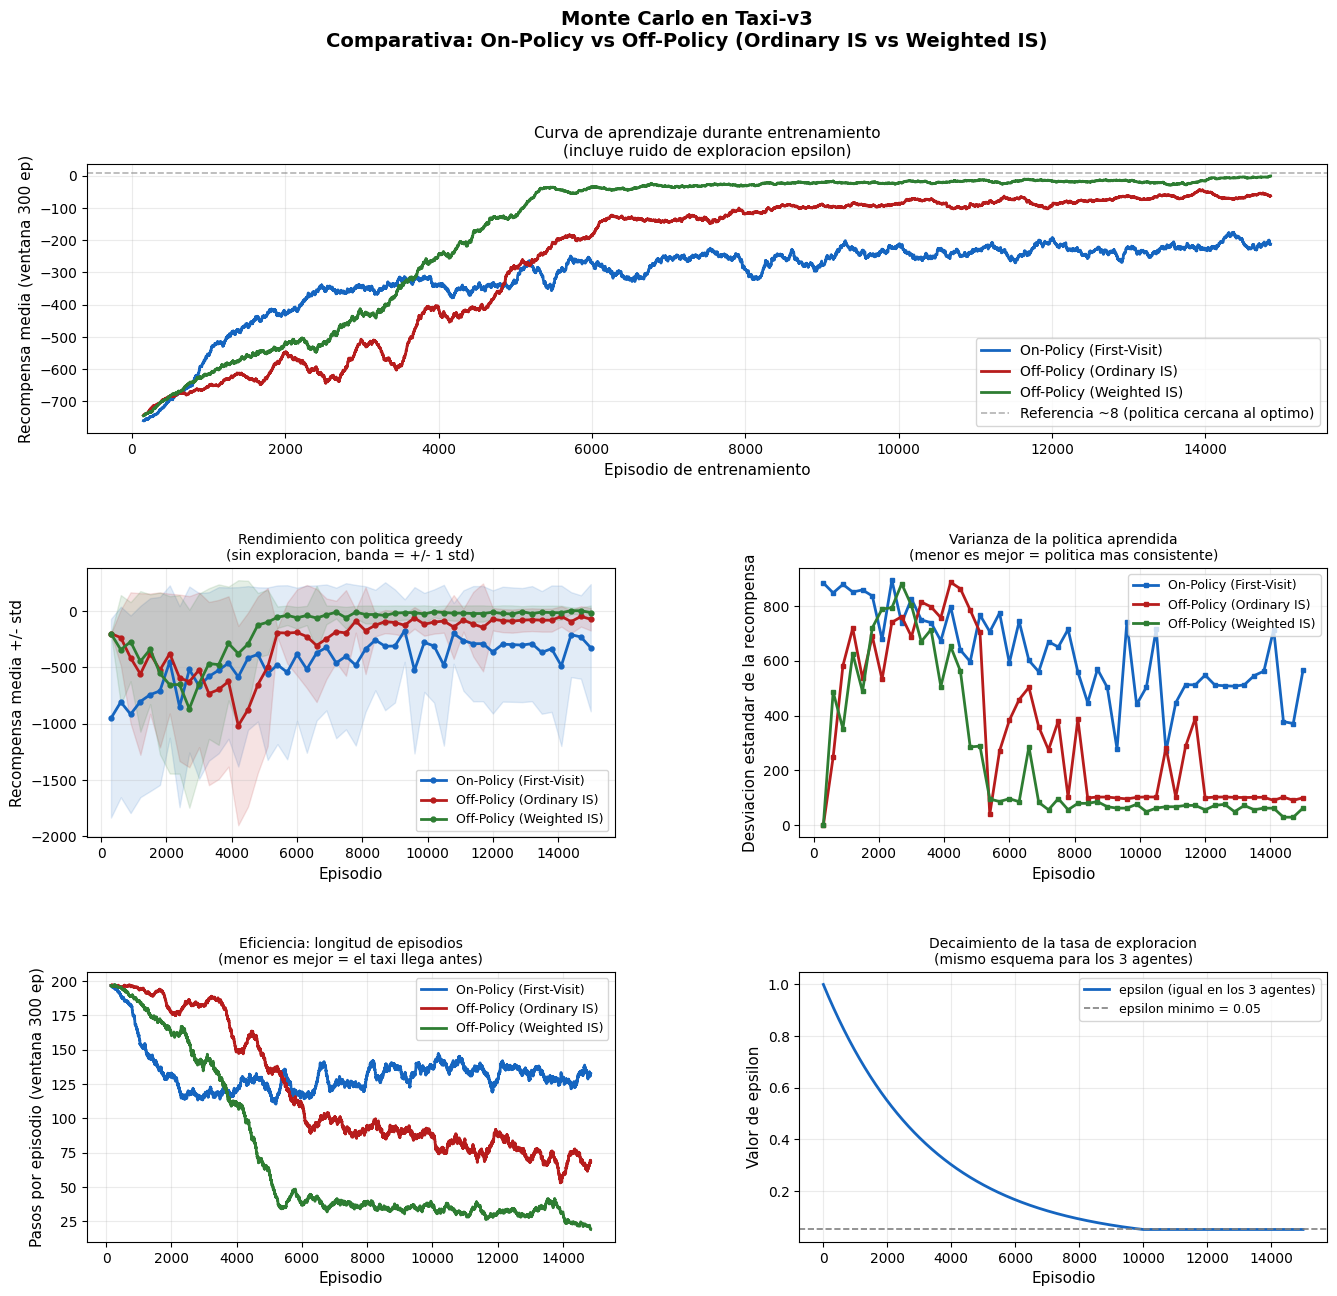

Figura guardada: mc_comparativa_triple.png


In [9]:
# ============================================================
# FIGURA PRINCIPAL: Comparativa triple
# ============================================================

# Paleta de colores consistente en todas las figuras
COLORS = {
    'on'  : '#1565C0',   # azul oscuro  -> On-Policy
    'ord' : '#B71C1C',   # rojo oscuro  -> Ordinary IS
    'wis' : '#2E7D32',   # verde oscuro -> Weighted IS
}
LABELS = {
    'on'  : 'On-Policy (First-Visit)',
    'ord' : 'Off-Policy (Ordinary IS)',
    'wis' : 'Off-Policy (Weighted IS)',
}
WINDOW = 300

fig = plt.figure(figsize=(16, 14))
fig.suptitle(
    'Monte Carlo en Taxi-v3\nComparativa: On-Policy vs Off-Policy (Ordinary IS vs Weighted IS)',
    fontsize=14, fontweight='bold', y=0.99
)
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.5, wspace=0.35)


# PLOT 1 (fila 0, span completo): Curva de aprendizaje en entrenamiento
# Muestra el reward bruto de entrenamiento suavizado.
# Incluye el ruido de la exploracion epsilon, por eso es peor que la evaluacion.
ax1 = fig.add_subplot(gs[0, :])

for key, train_r, color, label in [
    ('on',  train_on,  COLORS['on'],  LABELS['on']),
    ('ord', train_ord, COLORS['ord'], LABELS['ord']),
    ('wis', train_wis, COLORS['wis'], LABELS['wis']),
]:
    smoothed = smooth(train_r, WINDOW)
    x = np.arange(WINDOW // 2, len(smoothed) + WINDOW // 2)
    ax1.plot(x, smoothed, color=color, lw=2.0, label=label)

ax1.axhline(y=8, color='gray', ls='--', lw=1.2, alpha=0.6,
            label='Referencia ~8 (politica cercana al optimo)')
ax1.set_xlabel('Episodio de entrenamiento', fontsize=11)
ax1.set_ylabel(f'Recompensa media (ventana {WINDOW} ep)', fontsize=11)
ax1.set_title('Curva de aprendizaje durante entrenamiento\n'
              '(incluye ruido de exploracion epsilon)', fontsize=11)
ax1.legend(fontsize=10, loc='lower right')
ax1.grid(alpha=0.25)


# PLOT 2 (fila 1, col 0): Evaluacion periodica greedy
# Mide el rendimiento REAL del agente (sin exploracion).
# Es el indicador mas limpio del aprendizaje.
ax2 = fig.add_subplot(gs[1, 0])

for key, ev_r, ev_std, ev_eps, color, label in [
    ('on',  eval_on,  std_on,  eps_on,  COLORS['on'],  LABELS['on']),
    ('ord', eval_ord, std_ord, eps_ord, COLORS['ord'], LABELS['ord']),
    ('wis', eval_wis, std_wis, eps_wis, COLORS['wis'], LABELS['wis']),
]:
    ev_r_arr   = np.array(ev_r)
    ev_std_arr = np.array(ev_std)
    ax2.plot(ev_eps, ev_r_arr, color=color, lw=2.0, marker='o', ms=3.5, label=label)
    # Banda de confianza: mas estrecha = mas consistente
    ax2.fill_between(ev_eps, ev_r_arr - ev_std_arr, ev_r_arr + ev_std_arr,
                     alpha=0.12, color=color)

ax2.set_xlabel('Episodio', fontsize=11)
ax2.set_ylabel('Recompensa media +/- std', fontsize=11)
ax2.set_title('Rendimiento con politica greedy\n'
              '(sin exploracion, banda = +/- 1 std)', fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.25)


# PLOT 3 (fila 1, col 1): Varianza de la evaluacion
# Un agente bien entrenado tiene baja varianza: siempre obtiene resultados similares.
# Alta varianza = politica inconsistente o no convergida.
ax3 = fig.add_subplot(gs[1, 1])

for key, ev_std, ev_eps, color, label in [
    ('on',  std_on,  eps_on,  COLORS['on'],  LABELS['on']),
    ('ord', std_ord, eps_ord, COLORS['ord'], LABELS['ord']),
    ('wis', std_wis, eps_wis, COLORS['wis'], LABELS['wis']),
]:
    ax3.plot(ev_eps, ev_std, color=color, lw=2.0, marker='s', ms=3.5, label=label)

ax3.set_xlabel('Episodio', fontsize=11)
ax3.set_ylabel('Desviacion estandar de la recompensa', fontsize=11)
ax3.set_title('Varianza de la politica aprendida\n'
              '(menor es mejor = politica mas consistente)', fontsize=10)
ax3.legend(fontsize=9)
ax3.grid(alpha=0.25)


# PLOT 4 (fila 2, col 0): Longitud de episodios
# Un agente que aprende resuelve el taxi en menos pasos.
# Indicador indirecto de la calidad de la politica.
ax4 = fig.add_subplot(gs[2, 0])

for key, lengths, color, label in [
    ('on',  lengths_on,  COLORS['on'],  LABELS['on']),
    ('ord', lengths_ord, COLORS['ord'], LABELS['ord']),
    ('wis', lengths_wis, COLORS['wis'], LABELS['wis']),
]:
    smoothed = smooth(lengths, WINDOW)
    x = np.arange(WINDOW // 2, len(smoothed) + WINDOW // 2)
    ax4.plot(x, smoothed, color=color, lw=2.0, label=label)

ax4.set_xlabel('Episodio', fontsize=11)
ax4.set_ylabel(f'Pasos por episodio (ventana {WINDOW} ep)', fontsize=11)
ax4.set_title('Eficiencia: longitud de episodios\n'
              '(menor es mejor = el taxi llega antes)', fontsize=10)
ax4.legend(fontsize=9)
ax4.grid(alpha=0.25)


# PLOT 5 (fila 2, col 1): Decaimiento de epsilon
# Los tres agentes usan el mismo esquema.
# Contextualiza por que las curvas tienen mucho ruido al principio.
ax5 = fig.add_subplot(gs[2, 1])

ax5.plot(np.arange(len(eps_hist_on)), eps_hist_on,
         color=COLORS['on'], lw=2.0, label='epsilon (igual en los 3 agentes)')
ax5.axhline(y=EPSILON_END, color='gray', ls='--', lw=1.2,
            label=f'epsilon minimo = {EPSILON_END}')
ax5.set_xlabel('Episodio', fontsize=11)
ax5.set_ylabel('Valor de epsilon', fontsize=11)
ax5.set_title('Decaimiento de la tasa de exploracion\n'
              '(mismo esquema para los 3 agentes)', fontsize=10)
ax5.legend(fontsize=9)
ax5.grid(alpha=0.25)


plt.savefig('mc_comparativa_triple.png', dpi=130, bbox_inches='tight')
plt.show()
print("Figura guardada: mc_comparativa_triple.png")

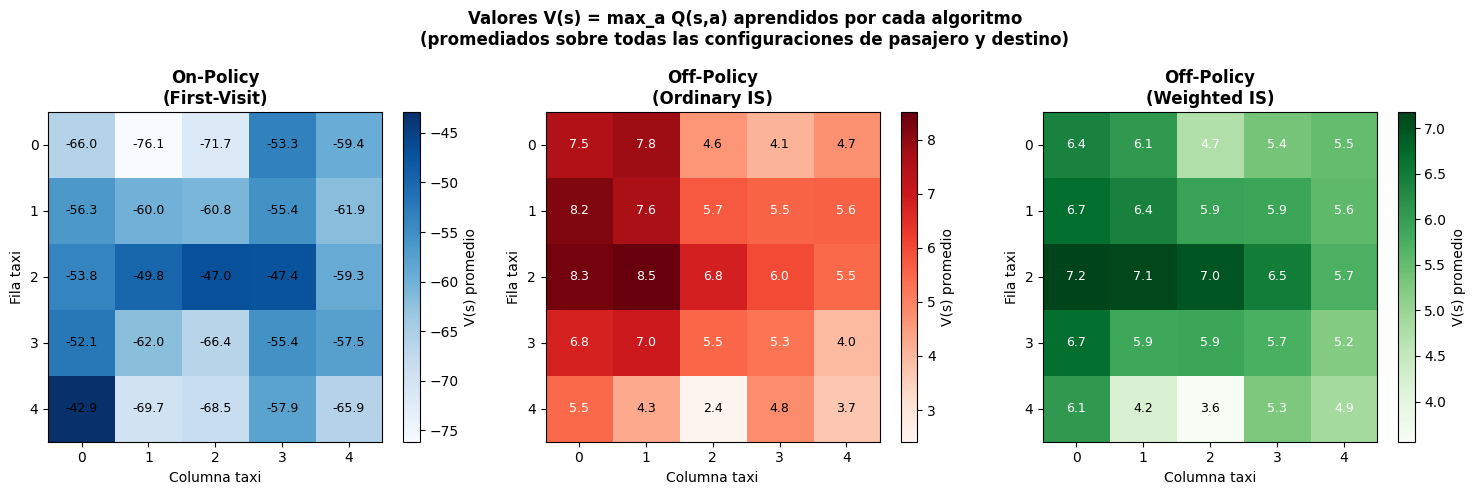

In [10]:
# ============================================================
# HEATMAP de valores Q aprendidos
#
# Muestra V(s) = max_a Q(s,a) para cada celda del grid 5x5.
# Un valor alto = el taxi, estando ahi, espera mucha recompensa futura.
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    'Valores V(s) = max_a Q(s,a) aprendidos por cada algoritmo\n'
    '(promediados sobre todas las configuraciones de pasajero y destino)',
    fontsize=12, fontweight='bold'
)

env_aux = gym.make('Taxi-v3')

for ax, Q_table, title, cmap in zip(
    axes,
    [Q_on, Q_ord, Q_wis],
    ['On-Policy\n(First-Visit)', 'Off-Policy\n(Ordinary IS)', 'Off-Policy\n(Weighted IS)'],
    ['Blues', 'Reds', 'Greens']
):
    grid  = np.zeros((5, 5))
    count = np.zeros((5, 5))

    for s in range(500):
        # decode(s) devuelve (fila_taxi, col_taxi, pos_pasajero, destino)
        row, col, _, _ = list(env_aux.unwrapped.decode(s))
        grid[row, col]  += np.max(Q_table[s])   # V(s) = max_a Q(s,a)
        count[row, col] += 1

    grid = np.where(count > 0, grid / count, 0)

    im = ax.imshow(grid, cmap=cmap, aspect='auto')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Columna taxi', fontsize=10)
    ax.set_ylabel('Fila taxi', fontsize=10)
    ax.set_xticks(range(5))
    ax.set_yticks(range(5))

    vmax = grid.max()
    for i in range(5):
        for j in range(5):
            color_text = 'white' if grid[i, j] > 0.6 * vmax else 'black'
            ax.text(j, i, f'{grid[i, j]:.1f}',
                    ha='center', va='center', fontsize=9, color=color_text)

    plt.colorbar(im, ax=ax, label='V(s) promedio')

env_aux.close()
plt.tight_layout()
plt.savefig('mc_heatmap_Q.png', dpi=120, bbox_inches='tight')
plt.show()

In [11]:
# ============================================================
# TABLA RESUMEN DE RESULTADOS
# ============================================================

def convergence_episode(eval_rewards, eval_episodes, threshold=5.0):
    """Primer episodio en que el agente supera 'threshold' de reward evaluado."""
    for ep, r in zip(eval_episodes, eval_rewards):
        if r >= threshold:
            return ep
    return 'No alcanzado'


THRESHOLD = 5.0

datos = {
    'Algoritmo': ['On-Policy (First-Visit)', 'Off-Policy (Ordinary IS)', 'Off-Policy (Weighted IS)'],
    'Reward final eval': [
        f"{eval_on[-1]:.2f} +/- {std_on[-1]:.2f}",
        f"{eval_ord[-1]:.2f} +/- {std_ord[-1]:.2f}",
        f"{eval_wis[-1]:.2f} +/- {std_wis[-1]:.2f}",
    ],
    'Mejor reward eval': [
        f"{max(eval_on):.2f}",
        f"{max(eval_ord):.2f}",
        f"{max(eval_wis):.2f}",
    ],
    f'Conv. (reward >= {THRESHOLD})': [
        convergence_episode(eval_on,  eps_on,  THRESHOLD),
        convergence_episode(eval_ord, eps_ord, THRESHOLD),
        convergence_episode(eval_wis, eps_wis, THRESHOLD),
    ],
    'Reward med. ultimos 1000 ep': [
        f"{np.mean(train_on[-1000:]):.2f}",
        f"{np.mean(train_ord[-1000:]):.2f}",
        f"{np.mean(train_wis[-1000:]):.2f}",
    ],
    'Longitud med. ultimos 1000 ep': [
        f"{np.mean(lengths_on[-1000:]):.1f} pasos",
        f"{np.mean(lengths_ord[-1000:]):.1f} pasos",
        f"{np.mean(lengths_wis[-1000:]):.1f} pasos",
    ],
}

df = pd.DataFrame(datos).set_index('Algoritmo')
print("\n" + "=" * 80)
print("TABLA COMPARATIVA DE RESULTADOS")
print("=" * 80)
print(df.to_string())
print("=" * 80)


TABLA COMPARATIVA DE RESULTADOS
                           Reward final eval Mejor reward eval Conv. (reward >= 5.0) Reward med. ultimos 1000 ep Longitud med. ultimos 1000 ep
Algoritmo                                                                                                                                     
On-Policy (First-Visit)   -325.20 +/- 565.58           -173.00          No alcanzado                     -211.46                   130.2 pasos
Off-Policy (Ordinary IS)    -72.32 +/- 99.98            -46.68          No alcanzado                      -63.06                    69.2 pasos
Off-Policy (Weighted IS)    -12.42 +/- 62.60              3.86          No alcanzado                       -5.41                    22.5 pasos


In [12]:
# ============================================================
# DEMOSTRACION: el agente actuando en el entorno
# ============================================================

env_demo = gym.make('Taxi-v3', render_mode='ansi')
state, _ = env_demo.reset(seed=7)
done = False; total_r = 0; steps = 0

ACTION_NAMES = ['Sur', 'Norte', 'Este', 'Oeste', 'Recoger', 'Dejar']

print("=" * 50)
print("Demo: agente On-Policy (politica greedy)")
print("=" * 50)

while not done and steps < 40:
    print(env_demo.render())
    action = int(np.argmax(Q_on[state]))
    print(f"  Paso {steps+1:02d}: {ACTION_NAMES[action]}")
    state, reward, terminated, truncated, _ = env_demo.step(action)
    total_r += reward
    done = terminated or truncated
    steps += 1

print(env_demo.render())
print(f"\nRecompensa total: {total_r}  |  Pasos: {steps}")
env_demo.close()

Demo: agente On-Policy (politica greedy)
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+


  Paso 01: Sur
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (South)

  Paso 02: Recoger
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (Pickup)

  Paso 03: Norte
+---------+
|R: | : :G|
| : | : : |
| : : : : |
|_| : | : |
|Y| : |B: |
+---------+
  (North)

  Paso 04: Oeste
+---------+
|R: | : :G|
| : | : : |
| : : : : |
|_| : | : |
|Y| : |B: |
+---------+
  (West)

  Paso 05: Oeste
+---------+
|R: | : :G|
| : | : : |
| : : : : |
|_| : | : |
|Y| : |B: |
+---------+
  (West)

  Paso 06: Oeste
+---------+
|R: | : :G|
| : | : : |
| : : : : |
|_| : | : |
|Y| : |B: |
+---------+
  (West)

  Paso 07: Oeste
+---------+
|R: | : :G|
| : | : : |
| : : : : |
|_| : | : |
|Y| : |B: |
+---------+
  (West)

  Paso 08: Oeste
+---------+
|R: | : :G|
| : | : : |
| : : : : |
|_| : | : |
|Y| : |B: |
+--

---
## Analisis y Conclusiones

### Diferencias observadas entre los tres algoritmos

**On-Policy (First-Visit)**
- Aprende la politica epsilon-greedy, no la greedy pura
- Curva de aprendizaje mas suave y estable
- Rendimiento final ligeramente inferior porque epsilon > 0 siempre

**Off-Policy Ordinary IS**
- Mayor varianza en las primeras fases (ratios W pueden ser grandes)
- El clipping de W ayuda pero introduce sesgo
- En teoria converge a la politica greedy optima

**Off-Policy Weighted IS**
- Varianza reducida gracias a la normalizacion por C(s,a)
- Convergencia mas estable que Ordinary IS
- Ligero sesgo (pero asintoticamente desaparece)
- **Preferido en la practica** para MC off-policy

### Por que MC tabular NO funciona en entornos continuos

| | Taxi-v3 (discreto) | MountainCar (continuo) |
|---|---|---|
| Estados | 500 (finitos) | Infinitos (posicion x velocidad en R^2) |
| Tabla Q | 500 x 6 = 3.000 entradas | Imposible representar |
| Visitas por estado | Repetibles | Practicamente 0 |
| Generalizacion | No necesaria | Imprescindible |

Solucion: **Aproximacion de funciones** (Parte 3 del trabajo)
- SARSA semi-gradiente: Q(s,a;w) con pesos lineales
- Deep Q-Learning: red neuronal que generaliza entre estados similares

### MC vs TD: diferencia fundamental

| | Monte Carlo | TD (SARSA, Q-Learning) |
|---|---|---|
| Cuando actualiza | Al final del episodio | En cada paso |
| Retorno usado | Real G_t | Estimado R + gamma*Q(s',a') |
| Sesgo | Sin sesgo | Con sesgo (bootstrap) |
| Varianza | Alta | Baja |
| Episodios completos | Necesarios | No necesarios |
| Entornos continuos | No directamente | Si |